# Análise de Consumo Energético — PPH 2019

Este notebook transforma o banco de dados bruto da pesquisa **PPH 2019** em uma
tabela única, com **uma linha por entrevista** e **uma coluna por informação
relevante**, cobrindo um conjunto ampliado de aparelhos:

- **Quantidade** de cada aparelho (arredondada para inteiro);
- **Consumo elétrico estimado** (kWh/mês) de cada aparelho;
- **Consumo total estimado** por entrevista (soma de todos os aparelhos);
- **Valor estimado da conta de luz** (R$), usando a tarifa de **R$ 0,75/kWh**;
- Um **ranking** dos aparelhos e categorias que mais consomem energia.

> Esta versão **remove** a seção de hábitos comportamentais e a decodificação
> de fonte de energia (mantendo o notebook focado apenas em quantidade e
> consumo). Mantém-se a identificação básica da entrevista (ENTREVISTA,
> REGIÃO, UF, MUNICÍPIO), pois é o que permite ligar cada linha a uma
> entrevista específica.

## Aparelhos incluídos, por categoria

| Categoria | Aparelhos |
|---|---|
| Refrigeração | Geladeira, Freezer, Frigobar, Bebedouro |
| Climatização | Ar-condicionado, Ar-condicionado Split, Ventilador, Ventilador de teto, Aquecedor elétrico |
| Tecnologia | Televisão, Computador (desktop), Notebook, Roteador Wi-Fi, Videogame, Caixa de som |
| Iluminação | Lâmpada LED, Lâmpada Fluorescente, Lâmpada Incandescente |
| Eletrodomésticos | Chuveiro Elétrico, Máquina de lavar, Secadora de roupas, Lava-louças, Micro-ondas, Forno elétrico, Fogão elétrico, Air Fryer, Cafeteira elétrica, Ferro de passar, Aspirador de pó, Secador de cabelo, Liquidificador, Batedeira, Máquina de costura |
| Serviços | Bomba d'água, Portão elétrico, Motor de piscina |

## Aproximações necessárias (documentadas ao longo do notebook)

- **Frigobar vs. Geladeira**: a pesquisa pergunta a quantidade total de
  refrigeradores e, separadamente, o **tipo predominante** (ex.: Frigobar,
  Refrigerador 1 porta, Combinado, Side-by-side). Não há como saber, dentro
  de uma casa com vários refrigeradores, quantos de cada tipo — então
  atribuímos a quantidade inteira ao tipo informado.
- **Ar-condicionado Split**: mesma lógica — subtipo (Janela / Portátil /
  Split comum / Split inverter) aplicado à quantidade total de
  ar-condicionados da entrevista.
- **Caixa de som** ≈ "Aparelho de som/rádio" (nome mais próximo no
  questionário).
- **Motor de piscina** ≈ "Filtro de Piscina" (no questionário PPH, esse item
  já engloba o conjunto motor+filtro usado nas piscinas residenciais).


## 1. Configuração e carregamento dos dados

In [7]:
%pip install numpy pandas openpyxl pathlib
import numpy as np
import pandas as pd
import openpyxl
from pathlib import Path

DATA_PATH = r"C:\Users\Usuario\Desktop\NOTEBOOK UPDATES\G9-BR-TEAM-18\data\raw\PPH 2019 - Banco de Dados V2 (2).xlsx"

xls = pd.ExcelFile(DATA_PATH)
df = xls.parse("Banco de Dados")

print(f"Banco de Dados: {df.shape[0]} entrevistas x {df.shape[1]} colunas")


Note: you may need to restart the kernel to use updated packages.
Banco de Dados: 27826 entrevistas x 2319 colunas


## 2. Funções utilitárias e premissas de cálculo

Mesmas escalas fixas de frequência (dias/mês) e duração (horas/uso) usadas
em praticamente todo o questionário, confirmadas comparando várias variáveis
na aba `Texto das alternativas`. Fórmula padrão de consumo:

```
kWh/mês = quantidade × (potência_W / 1000) × horas por uso × dias de uso/mês
```


In [8]:
MAPA_FREQUENCIA_DIAS_MES = {1: 28.2, 2: 19.6, 3: 10.9, 4: 4.3, 5: 2.0, 6: 1.0, 7: 0.0}
MAPA_DURACAO_HORAS = {1: 10/60, 2: 20.5/60, 3: 45.5/60, 4: 90/60,
                      5: 3.0, 6: 5.0, 7: 9.0, 8: 18.0, 9: 24.0}


def _col(name):
    return df[name] if name in df.columns else pd.Series(np.nan, index=df.index)


def num(name):
    return pd.to_numeric(_col(name), errors="coerce")


def qtd(name):
    """Quantidade de um aparelho: 0 quando não respondido/não aplicável."""
    return num(name).fillna(0)


def dias_uso_mes(name):
    return num(name).map(MAPA_FREQUENCIA_DIAS_MES).fillna(0.0)


def horas_por_uso(name):
    return num(name).map(MAPA_DURACAO_HORAS).fillna(0.0)


def txt_quantidade(base_name):
    """Para colunas 'dummy + _TXT' (ex.: lâmpadas): a quantidade real
    informada está em '<base_name>_TXT', não na coluna numérica principal."""
    return qtd(f"{base_name}_TXT")


def horas_dummy(prefix):
    """Conta quantas colunas-hora (prefix_0 .. prefix_23) estão marcadas
    = número estimado de horas de uso por dia."""
    cols = [f"{prefix}_{h}" for h in range(24) if f"{prefix}_{h}" in df.columns]
    if not cols:
        return pd.Series(0.0, index=df.index)
    return df[cols].notna().sum(axis=1)


def kwh_padrao(quantidade, potencia_w, freq_name, dur_name):
    return quantidade * (potencia_w / 1000) * horas_por_uso(dur_name) * dias_uso_mes(freq_name)


## 3. Refrigeração — Geladeira, Freezer, Frigobar, Bebedouro

In [9]:
# A pesquisa pergunta a quantidade TOTAL de refrigeradores (P7.1) e,
# separadamente, o TIPO predominante (P7.1.1.2). Tipo 1 = Frigobar; os
# demais tipos (2 a 6) são geladeiras "normais" (1 porta, combinado,
# side-by-side etc). Ver observação de aproximação na introdução.
qtd_ref_total = qtd("P7.1")
tipo_ref = num("P7.1.1.2")
qtd_frigobar = qtd_ref_total.where(tipo_ref == 1, 0)
qtd_geladeira = qtd_ref_total.where(tipo_ref != 1, 0)

# Geladeira/frigobar/freezer ficam ligados 24h/dia -> a pesquisa não
# pergunta frequência/tempo de uso para eles, então usamos consumo médio
# fixo por unidade (premissas de mercado, aparelhos classe A):
GELADEIRA_KWH_MES_UNIDADE = 45.0
FRIGOBAR_KWH_MES_UNIDADE = 25.0   # unidade menor, compressor menos potente
FREEZER_KWH_MES_UNIDADE = 40.0

kwh_geladeira = qtd_geladeira * GELADEIRA_KWH_MES_UNIDADE
kwh_frigobar = qtd_frigobar * FRIGOBAR_KWH_MES_UNIDADE

qtd_freezer = qtd("P7.2")
kwh_freezer = qtd_freezer * FREEZER_KWH_MES_UNIDADE

# Bebedouro/purificador/filtro: TEM frequência e duração de uso reais no
# questionário (ao contrário de geladeira/freezer) -> usamos a fórmula
# padrão. Potência assumida ~90W (compressor pequeno, típico de mercado).
POT_BEBEDOURO_W = 90
qtd_bebedouro = qtd("P9.2.2.15")
kwh_bebedouro = kwh_padrao(qtd_bebedouro, POT_BEBEDOURO_W, "P9.2.4.15", "P9.2.3.15")

print(qtd_geladeira.describe())
print(qtd_frigobar.describe())
print(qtd_freezer.describe())
print(qtd_bebedouro.describe())


count    27826.000000
mean         0.682204
std          0.518922
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          5.000000
Name: P7.1, dtype: float64
count    27826.000000
mean         0.004995
std          0.077774
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          4.000000
Name: P7.1, dtype: float64
count    27826.000000
mean         0.114282
std          0.341583
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          7.000000
Name: P7.2, dtype: float64
count    27826.000000
mean         0.054086
std          0.227459
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          2.000000
Name: P9.2.2.15, dtype: float64


## 4. Climatização — Ar-condicionado (+ Split), Ventilador, Ventilador de teto, Aquecedor elétrico

In [10]:
# Ar-condicionado: potência a partir da capacidade em BTU/h (regra prática
# de mercado ~10 BTU/h por Watt). Horas/dia via colunas de horário; dias de
# uso/mês = média das frequências mensais (jan-dez) informadas.
BTU_MEDIO = {1: 6750, 2: 8750, 3: 11000, 4: 15000, 5: 21000, 6: 27000}

qtd_ac_total = qtd("P7.3")
tipo_ac_capacidade = num("P7.3.1.3")     # capacidade BTU/h (categórica)
tipo_ac_categoria = num("P7.3.1.2")      # 1=Janela 2=Portátil 3=Split comum 4=Split inverter 5=Outro

potencia_ac_w = tipo_ac_capacidade.map(BTU_MEDIO).fillna(0) / 10.0
horas_ac_dia = horas_dummy("P7.3.2.2")
dias_uso_mes_ac_media = sum(dias_uso_mes(f"P7.3.2.4.{m}") for m in range(1, 13)) / 12.0
kwh_ac_unitario_fator = (potencia_ac_w / 1000) * horas_ac_dia * dias_uso_mes_ac_media

# Ar-condicionado (todos os tipos)
kwh_ar_condicionado = qtd_ac_total * kwh_ac_unitario_fator

# Ar-condicionado Split (subconjunto por tipo, mesma aproximação usada no
# Frigobar: quantidade total atribuída ao tipo predominante informado)
qtd_ac_split = qtd_ac_total.where(tipo_ac_categoria.isin([3, 4]), 0)
kwh_ac_split = qtd_ac_split * kwh_ac_unitario_fator

# Ventiladores: dois subtipos distintos no questionário.
POT_VENTILADOR_TETO_W = 100
POT_VENTILADOR_CIRC_W = 70

qtd_ventilador_teto = qtd("P9.2.2.9")
kwh_ventilador_teto = kwh_padrao(qtd_ventilador_teto, POT_VENTILADOR_TETO_W, "P9.2.4.9", "P9.2.3.9")

qtd_ventilador = qtd("P9.2.2.10")   # ventilador/circulador "comum"
kwh_ventilador = kwh_padrao(qtd_ventilador, POT_VENTILADOR_CIRC_W, "P9.2.4.10", "P9.2.3.10")

# Aquecedor elétrico (aquecedor de ambiente)
POT_AQUECEDOR_W = 1500
qtd_aquecedor_eletrico = qtd("P9.2.2.8")
kwh_aquecedor_eletrico = kwh_padrao(qtd_aquecedor_eletrico, POT_AQUECEDOR_W, "P9.2.4.8", "P9.2.3.8")

print(qtd_ac_total.describe())
print(qtd_ac_split.describe())
print(qtd_ventilador_teto.describe())
print(qtd_ventilador.describe())
print(qtd_aquecedor_eletrico.describe())


count    27826.000000
mean         0.145655
std          0.455402
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          6.000000
Name: P7.3, dtype: float64
count    27826.000000
mean         0.095989
std          0.380599
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          6.000000
Name: P7.3, dtype: float64
count    27826.000000
mean         0.074858
std          0.358948
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          5.000000
Name: P9.2.2.9, dtype: float64
count    27826.000000
mean         0.857148
std          1.007593
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          5.000000
Name: P9.2.2.10, dtype: float64
count    27826.000000
mean         0.002695
std          0.056492
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          3.000000
Nam

## 5. Tecnologia — TV, Computador, Notebook, Roteador Wi-Fi, Videogame, Caixa de som

In [11]:
POT_TV_W = 120
qtd_tv = qtd("P8.1")
horas_tv = horas_dummy("P8.1.1.2")
freq_tv = dias_uso_mes("P8.1.1.4")
kwh_tv = qtd_tv * (POT_TV_W / 1000) * horas_tv * freq_tv

POT_DESKTOP_W = 200
qtd_computador_desktop = qtd("P9.2.2.14")
kwh_computador_desktop = kwh_padrao(qtd_computador_desktop, POT_DESKTOP_W, "P9.2.4.14", "P9.2.3.14")

POT_NOTEBOOK_W = 60
qtd_notebook = qtd("P9.2.2.12")
kwh_notebook = kwh_padrao(qtd_notebook, POT_NOTEBOOK_W, "P9.2.4.12", "P9.2.3.12")

# Roteador Wi-Fi: soma do roteador próprio do morador + do modem-roteador
# fornecido pela operadora (as duas variantes perguntadas no questionário).
POT_ROTEADOR_W = 10
qtd_roteador_proprio = qtd("P9.1.2.23")
kwh_roteador_proprio = kwh_padrao(qtd_roteador_proprio, POT_ROTEADOR_W, "P9.1.4.23", "P9.1.3.23")
qtd_roteador_operadora = qtd("P9.1.2.22")
kwh_roteador_operadora = kwh_padrao(qtd_roteador_operadora, POT_ROTEADOR_W, "P9.1.4.22", "P9.1.3.22")
qtd_roteador_wifi = qtd_roteador_proprio + qtd_roteador_operadora
kwh_roteador_wifi = kwh_roteador_proprio + kwh_roteador_operadora

POT_VIDEOGAME_W = 150
qtd_videogame = qtd("P9.2.2.11")
kwh_videogame = kwh_padrao(qtd_videogame, POT_VIDEOGAME_W, "P9.2.4.11", "P9.2.3.11")

# Caixa de som ~ "Aparelho de som/rádio" (item mais próximo no questionário)
POT_CAIXA_SOM_W = 50
qtd_caixa_som = qtd("P9.2.2.13")
kwh_caixa_som = kwh_padrao(qtd_caixa_som, POT_CAIXA_SOM_W, "P9.2.4.13", "P9.2.3.13")

print(qtd_tv.describe())
print(qtd_computador_desktop.describe())
print(qtd_notebook.describe())
print(qtd_roteador_wifi.describe())
print(qtd_videogame.describe())
print(qtd_caixa_som.describe())


count    27826.000000
mean         0.871882
std          0.793284
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          7.000000
Name: P8.1, dtype: float64
count    27826.000000
mean         0.120319
std          0.384197
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          4.000000
Name: P9.2.2.14, dtype: float64
count    27826.000000
mean         0.196004
std          0.512240
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          5.000000
Name: P9.2.2.12, dtype: float64
count    27826.000000
mean         0.310142
std          0.526375
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          6.000000
dtype: float64
count    27826.000000
mean         0.032128
std          0.189507
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          4.000000
Name: P9.2.2.1

## 6. Iluminação — Lâmpada LED, Fluorescente, Incandescente

A pesquisa detalha 26 tecnologias de lâmpada por cômodo. Agrupamos essas 26
tecnologias em 3 grandes famílias (a pesquisa também inclui dicroica
halógena, mini dicroica halógena e "outros", que não se encaixam em
nenhuma das 3 famílias pedidas — por isso ficam fora desta contagem, sem
inventar uma categoria extra que não foi solicitada).


In [12]:
POTENCIA_LAMPADA_W = {
    1: 60, 2: 40, 3: 60, 4: 100, 5: 150,             # incandescentes
    6: 15, 7: 12, 8: 14.5, 9: 21, 10: 26,             # fluorescente compacta
    11: 110, 12: 40, 13: 20,                          # fluorescente tubular G/M/P
    14: 10, 15: 8, 16: 10, 17: 13.5, 18: 16,           # LED
    19: 40, 20: 18, 21: 9,                            # tubo LED G/M/P
    23: 6, 25: 4,                                     # dicroica/mini dicroica LED
}
TIPOS_INCANDESCENTE = [1, 2, 3, 4, 5]
TIPOS_FLUORESCENTE = [6, 7, 8, 9, 10, 11, 12, 13]
TIPOS_LED = [14, 15, 16, 17, 18, 19, 20, 21, 23, 25]

ROOMS_COM_HORARIO = [1, 3, 5, 6, 7, 8, 9, 10, 11, 12]
HORAS_PADRAO_EVENTUAL = 1.0

qtd_lampada_led = pd.Series(0.0, index=df.index)
qtd_lampada_fluorescente = pd.Series(0.0, index=df.index)
qtd_lampada_incandescente = pd.Series(0.0, index=df.index)
kwh_lampada_led = pd.Series(0.0, index=df.index)
kwh_lampada_fluorescente = pd.Series(0.0, index=df.index)
kwh_lampada_incandescente = pd.Series(0.0, index=df.index)

for room in range(1, 13):
    horas = horas_dummy(f"P6.1.3.{room}") if room in ROOMS_COM_HORARIO \
        else pd.Series(HORAS_PADRAO_EVENTUAL, index=df.index)

    for grupo_tipos, destino in [
        (TIPOS_INCANDESCENTE, "incandescente"),
        (TIPOS_FLUORESCENTE, "fluorescente"),
        (TIPOS_LED, "led"),
    ]:
        q_grupo = pd.Series(0.0, index=df.index)
        w_grupo = pd.Series(0.0, index=df.index)
        for tipo in grupo_tipos:
            base = f"P6.1.2.{room}_{tipo}"
            if f"{base}_TXT" in df.columns:
                q = txt_quantidade(base)
                q_grupo += q
                w_grupo += q * POTENCIA_LAMPADA_W[tipo]
        kwh_grupo = (w_grupo / 1000) * horas * 30
        if destino == "incandescente":
            qtd_lampada_incandescente += q_grupo
            kwh_lampada_incandescente += kwh_grupo
        elif destino == "fluorescente":
            qtd_lampada_fluorescente += q_grupo
            kwh_lampada_fluorescente += kwh_grupo
        else:
            qtd_lampada_led += q_grupo
            kwh_lampada_led += kwh_grupo

print(qtd_lampada_led.describe())
print(qtd_lampada_fluorescente.describe())
print(qtd_lampada_incandescente.describe())


count    27826.000000
mean         1.444764
std          2.895122
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         37.000000
dtype: float64
count    27826.000000
mean         2.525516
std          3.155089
min          0.000000
25%          0.000000
50%          1.000000
75%          5.000000
max         44.000000
dtype: float64
count    27826.000000
mean         0.370804
std          1.432068
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         23.000000
dtype: float64


## 7. Eletrodomésticos

Chuveiro Elétrico, Máquina de lavar, Secadora de roupas, Lava-louças,
Micro-ondas, Forno elétrico, Fogão elétrico, Air Fryer, Cafeteira elétrica,
Ferro de passar, Aspirador de pó, Secador de cabelo, Liquidificador,
Batedeira, Máquina de costura.


In [13]:
# Chuveiro elétrico: único aparelho (além do AC) com potência REAL
# declarada pelo entrevistado -> não é premissa de mercado.
POTENCIA_CHUVEIRO_W = {1: 4000, 2: 5250, 3: 6750, 4: 8000, 9: 5500}
DURACAO_BANHO_H = {1: 2.5/60, 2: 8/60, 3: 15.5/60, 4: 25/60, 9: 10/60}
qtd_chuveiro_eletrico = qtd("P10.8")
pot_chuveiro = num("P10.9.4").map(POTENCIA_CHUVEIRO_W).fillna(5500)
vezes_dia_chuveiro = num("P10.9.5").fillna(0)
duracao_banho = num("P10.9.D").map(DURACAO_BANHO_H).fillna(10/60)
kwh_chuveiro_eletrico = qtd_chuveiro_eletrico * (pot_chuveiro / 1000) * vezes_dia_chuveiro * duracao_banho * 30

# Máquina de lavar (todos os tipos: automática, automática lava-e-seca,
# semiautomática/tanquinho) -> agora como coluna própria, sem somar com
# a secadora.
POT_MAQUINA_LAVAR_W = 700
DURACAO_CICLO_LAVAGEM_H = 1.0
qtd_maquina_lavar = qtd("P8.3")
lavagens_dia = txt_quantidade("P8.3.1.5")
freq_maquina_lavar = dias_uso_mes("P8.3.1.6")
kwh_maquina_lavar = (qtd_maquina_lavar * (POT_MAQUINA_LAVAR_W / 1000)
                     * lavagens_dia * DURACAO_CICLO_LAVAGEM_H * freq_maquina_lavar)

# Secadora de roupas (por aquecimento + centrífuga), coluna própria.
POT_SECADORA_AQUECIMENTO_W = 3000
POT_SECADORA_CENTRIFUGA_W = 400
qtd_secadora_aquec = qtd("P9.2.2.6")
kwh_secadora_aquec = kwh_padrao(qtd_secadora_aquec, POT_SECADORA_AQUECIMENTO_W, "P9.2.4.6", "P9.2.3.6")
qtd_secadora_centr = qtd("P9.2.2.7")
kwh_secadora_centr = kwh_padrao(qtd_secadora_centr, POT_SECADORA_CENTRIFUGA_W, "P9.2.4.7", "P9.2.3.7")
qtd_secadora_roupas = qtd_secadora_aquec + qtd_secadora_centr
kwh_secadora_roupas = kwh_secadora_aquec + kwh_secadora_centr

POT_LAVA_LOUCAS_W = 1200
qtd_lava_loucas = qtd("P9.2.2.2")
kwh_lava_loucas = kwh_padrao(qtd_lava_loucas, POT_LAVA_LOUCAS_W, "P9.2.4.2", "P9.2.3.2")

POT_MICROONDAS_W = 1200
qtd_microondas = qtd("P8.2")
kwh_microondas = kwh_padrao(qtd_microondas, POT_MICROONDAS_W, "P8.2.1.4", "P8.2.1.3")

POT_FORNO_ELETRICO_W = 1500
qtd_forno_eletrico = qtd("P9.2.2.1")
kwh_forno_eletrico = kwh_padrao(qtd_forno_eletrico, POT_FORNO_ELETRICO_W, "P9.2.4.1", "P9.2.3.1")

POT_FOGAO_ELETRICO_W = 2000
qtd_fogao_eletrico = qtd("P9.1.2.11")
kwh_fogao_eletrico = kwh_padrao(qtd_fogao_eletrico, POT_FOGAO_ELETRICO_W, "P9.1.4.11", "P9.1.3.11")

POT_AIRFRYER_W = 1500
qtd_air_fryer = qtd("P9.1.2.13")
kwh_air_fryer = kwh_padrao(qtd_air_fryer, POT_AIRFRYER_W, "P9.1.4.13", "P9.1.3.13")

POT_CAFETEIRA_W = 800
qtd_cafeteira_eletrica = qtd("P9.1.2.2")
kwh_cafeteira_eletrica = kwh_padrao(qtd_cafeteira_eletrica, POT_CAFETEIRA_W, "P9.1.4.2", "P9.1.3.2")

# Ferro de passar: soma dos 3 subtipos do questionário (a seco, a vapor
# usando vapor, a vapor sem usar vapor).
POT_FERRO_W = 1200
qtd_ferro_seco = qtd("P9.2.2.3")
kwh_ferro_seco = kwh_padrao(qtd_ferro_seco, POT_FERRO_W, "P9.2.4.3", "P9.2.3.3")
qtd_ferro_vapor1 = qtd("P9.2.2.4")
kwh_ferro_vapor1 = kwh_padrao(qtd_ferro_vapor1, POT_FERRO_W, "P9.2.4.4", "P9.2.3.4")
qtd_ferro_vapor2 = qtd("P9.2.2.5")
kwh_ferro_vapor2 = kwh_padrao(qtd_ferro_vapor2, POT_FERRO_W, "P9.2.4.5", "P9.2.3.5")
qtd_ferro_passar = qtd_ferro_seco + qtd_ferro_vapor1 + qtd_ferro_vapor2
kwh_ferro_passar = kwh_ferro_seco + kwh_ferro_vapor1 + kwh_ferro_vapor2

POT_ASPIRADOR_W = 1400
qtd_aspirador_po = qtd("P9.1.2.15")
kwh_aspirador_po = kwh_padrao(qtd_aspirador_po, POT_ASPIRADOR_W, "P9.1.4.15", "P9.1.3.15")

POT_SECADOR_CABELO_W = 1800
qtd_secador_cabelo = qtd("P9.1.2.40")
kwh_secador_cabelo = kwh_padrao(qtd_secador_cabelo, POT_SECADOR_CABELO_W, "P9.1.4.40", "P9.1.3.40")

POT_LIQUIDIFICADOR_W = 600
qtd_liquidificador = qtd("P9.1.2.5")
kwh_liquidificador = kwh_padrao(qtd_liquidificador, POT_LIQUIDIFICADOR_W, "P9.1.4.5", "P9.1.3.5")

POT_BATEDEIRA_W = 300
qtd_batedeira = qtd("P9.1.2.1")
kwh_batedeira = kwh_padrao(qtd_batedeira, POT_BATEDEIRA_W, "P9.1.4.1", "P9.1.3.1")

POT_MAQUINA_COSTURA_W = 100
qtd_maquina_costura = qtd("P9.1.2.38")
kwh_maquina_costura = kwh_padrao(qtd_maquina_costura, POT_MAQUINA_COSTURA_W, "P9.1.4.38", "P9.1.3.38")

print(qtd_chuveiro_eletrico.describe())
print(qtd_maquina_lavar.describe())
print(qtd_secadora_roupas.describe())
print(qtd_lava_loucas.describe())


count    27826.000000
mean         0.846942
std          0.735815
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          6.000000
Name: P10.8, dtype: float64
count    27826.000000
mean         0.453281
std          0.513458
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          4.000000
Name: P8.3, dtype: float64
count    27826.000000
mean         0.040466
std          0.205446
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          6.000000
dtype: float64
count    27826.000000
mean         0.008769
std          0.096266
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          2.000000
Name: P9.2.2.2, dtype: float64


## 8. Serviços — Bomba d'água, Portão elétrico, Motor de piscina

In [14]:
POT_BOMBA_DAGUA_W = 750
qtd_bomba_dagua = qtd("P9.1.2.37")
kwh_bomba_dagua = kwh_padrao(qtd_bomba_dagua, POT_BOMBA_DAGUA_W, "P9.1.4.37", "P9.1.3.37")

POT_PORTAO_ELETRICO_W = 300
qtd_portao_eletrico = qtd("P9.1.2.33")
kwh_portao_eletrico = kwh_padrao(qtd_portao_eletrico, POT_PORTAO_ELETRICO_W, "P9.1.4.33", "P9.1.3.33")

# Motor de piscina ~ "Filtro de Piscina" (equipamento equivalente no
# questionário - ver observação de aproximação na introdução).
POT_MOTOR_PISCINA_W = 750
qtd_motor_piscina = qtd("P9.1.2.36")
kwh_motor_piscina = kwh_padrao(qtd_motor_piscina, POT_MOTOR_PISCINA_W, "P9.1.4.36", "P9.1.3.36")

print(qtd_bomba_dagua.describe())
print(qtd_portao_eletrico.describe())
print(qtd_motor_piscina.describe())


count    27826.000000
mean         0.033494
std          0.181318
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          2.000000
Name: P9.1.2.37, dtype: float64
count    27826.000000
mean         0.035219
std          0.190095
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          4.000000
Name: P9.1.2.33, dtype: float64
count    27826.000000
mean         0.003809
std          0.064455
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          2.000000
Name: P9.1.2.36, dtype: float64


## 9. Consolidação da tabela final

- **Quantidades**: arredondadas para inteiro (`round().astype(int)`).
- **Consumo por aparelho** (kWh/mês): mantido em float, 2 casas decimais.
- **Consumo total** (kWh/mês): soma de todos os aparelhos, por entrevista.
- **Valor estimado da conta** (R$): `consumo_total_kwh_mes × 0,75`.


In [15]:
TARIFA_RS_POR_KWH = 0.75

base = df[["ENTREVISTA", "REGIAO", "UF", "MUNICIPIO"]].copy()

quantidades = pd.DataFrame({
    # Refrigeracao
    "qtd_geladeira": qtd_geladeira,
    "qtd_freezer": qtd_freezer,
    "qtd_frigobar": qtd_frigobar,
    "qtd_bebedouro": qtd_bebedouro,
    # Climatizacao
    "qtd_ar_condicionado": qtd_ac_total,
    "qtd_ar_condicionado_split": qtd_ac_split,
    "qtd_ventilador": qtd_ventilador,
    "qtd_ventilador_teto": qtd_ventilador_teto,
    "qtd_aquecedor_eletrico": qtd_aquecedor_eletrico,
    # Tecnologia
    "qtd_tv": qtd_tv,
    "qtd_computador_desktop": qtd_computador_desktop,
    "qtd_notebook": qtd_notebook,
    "qtd_roteador_wifi": qtd_roteador_wifi,
    "qtd_videogame": qtd_videogame,
    "qtd_caixa_som": qtd_caixa_som,
    # Iluminacao
    "qtd_lampada_led": qtd_lampada_led,
    "qtd_lampada_fluorescente": qtd_lampada_fluorescente,
    "qtd_lampada_incandescente": qtd_lampada_incandescente,
    # Eletrodomesticos
    "qtd_chuveiro_eletrico": qtd_chuveiro_eletrico,
    "qtd_maquina_lavar": qtd_maquina_lavar,
    "qtd_secadora_roupas": qtd_secadora_roupas,
    "qtd_lava_loucas": qtd_lava_loucas,
    "qtd_microondas": qtd_microondas,
    "qtd_forno_eletrico": qtd_forno_eletrico,
    "qtd_fogao_eletrico": qtd_fogao_eletrico,
    "qtd_air_fryer": qtd_air_fryer,
    "qtd_cafeteira_eletrica": qtd_cafeteira_eletrica,
    "qtd_ferro_passar": qtd_ferro_passar,
    "qtd_aspirador_po": qtd_aspirador_po,
    "qtd_secador_cabelo": qtd_secador_cabelo,
    "qtd_liquidificador": qtd_liquidificador,
    "qtd_batedeira": qtd_batedeira,
    "qtd_maquina_costura": qtd_maquina_costura,
    # Servicos
    "qtd_bomba_dagua": qtd_bomba_dagua,
    "qtd_portao_eletrico": qtd_portao_eletrico,
    "qtd_motor_piscina": qtd_motor_piscina,
}).round(0).astype(int)

consumo_kwh = pd.DataFrame({
    "kwh_geladeira": kwh_geladeira,
    "kwh_freezer": kwh_freezer,
    "kwh_frigobar": kwh_frigobar,
    "kwh_bebedouro": kwh_bebedouro,
    "kwh_ar_condicionado": kwh_ar_condicionado,
    "kwh_ar_condicionado_split": kwh_ac_split,
    "kwh_ventilador": kwh_ventilador,
    "kwh_ventilador_teto": kwh_ventilador_teto,
    "kwh_aquecedor_eletrico": kwh_aquecedor_eletrico,
    "kwh_tv": kwh_tv,
    "kwh_computador_desktop": kwh_computador_desktop,
    "kwh_notebook": kwh_notebook,
    "kwh_roteador_wifi": kwh_roteador_wifi,
    "kwh_videogame": kwh_videogame,
    "kwh_caixa_som": kwh_caixa_som,
    "kwh_lampada_led": kwh_lampada_led,
    "kwh_lampada_fluorescente": kwh_lampada_fluorescente,
    "kwh_lampada_incandescente": kwh_lampada_incandescente,
    "kwh_chuveiro_eletrico": kwh_chuveiro_eletrico,
    "kwh_maquina_lavar": kwh_maquina_lavar,
    "kwh_secadora_roupas": kwh_secadora_roupas,
    "kwh_lava_loucas": kwh_lava_loucas,
    "kwh_microondas": kwh_microondas,
    "kwh_forno_eletrico": kwh_forno_eletrico,
    "kwh_fogao_eletrico": kwh_fogao_eletrico,
    "kwh_air_fryer": kwh_air_fryer,
    "kwh_cafeteira_eletrica": kwh_cafeteira_eletrica,
    "kwh_ferro_passar": kwh_ferro_passar,
    "kwh_aspirador_po": kwh_aspirador_po,
    "kwh_secador_cabelo": kwh_secador_cabelo,
    "kwh_liquidificador": kwh_liquidificador,
    "kwh_batedeira": kwh_batedeira,
    "kwh_maquina_costura": kwh_maquina_costura,
    "kwh_bomba_dagua": kwh_bomba_dagua,
    "kwh_portao_eletrico": kwh_portao_eletrico,
    "kwh_motor_piscina": kwh_motor_piscina,
}).round(2)

# NOTA: kwh_ar_condicionado JA inclui os splits (ar_condicionado_split e um
# subconjunto de ar_condicionado). Para nao contar consumo em dobro no total,
# somamos apenas as colunas "pai" (nao as subcategorias) no total geral.
COLUNAS_PARA_TOTAL = [c for c in consumo_kwh.columns if c != "kwh_ar_condicionado_split"]

consumo_total_kwh_mes = consumo_kwh[COLUNAS_PARA_TOTAL].sum(axis=1).round(2)
valor_estimado_conta_reais = (consumo_total_kwh_mes * TARIFA_RS_POR_KWH).round(2)

df_final = pd.concat([base, quantidades, consumo_kwh], axis=1)
df_final["consumo_total_kwh_mes"] = consumo_total_kwh_mes
df_final["valor_estimado_conta_reais"] = valor_estimado_conta_reais

print(f"Tabela final: {df_final.shape[0]} entrevistas x {df_final.shape[1]} colunas")
df_final.head()


Tabela final: 27826 entrevistas x 78 colunas


,ENTREVISTA,REGIAO,UF,MUNICIPIO,qtd_geladeira,qtd_freezer,qtd_frigobar,qtd_bebedouro,qtd_ar_condicionado,qtd_ar_condicionado_split,...,kwh_aspirador_po,kwh_secador_cabelo,kwh_liquidificador,kwh_batedeira,kwh_maquina_costura,kwh_bomba_dagua,kwh_portao_eletrico,kwh_motor_piscina,consumo_total_kwh_mes,valor_estimado_conta_reais
0,52641,Norte,RR,Boa Vista,1,0,0,0,2,2,...,0.0,0.0,0.10,0.05,0.0,0.0,0.0,0.0,59.01,44.26
1,52642,Norte,RR,Boa Vista,1,0,0,0,4,4,...,0.0,6.7,0.20,0.00,0.0,0.0,0.0,0.0,82.31,61.73
2,52643,Norte,RR,Boa Vista,1,0,0,0,2,2,...,0.0,0.0,0.10,0.00,0.0,0.0,0.0,0.0,53.86,40.39
3,52647,Norte,RR,Boa Vista,1,0,0,0,1,0,...,0.0,0.0,1.09,0.00,0.0,0.0,0.0,0.0,109.23,81.92
4,52649,Norte,RR,Boa Vista,1,0,0,0,1,0,...,0.0,0.0,0.20,0.00,0.0,0.0,0.0,0.0,62.65,46.99


## 10. Rankings

- **Top 3 aparelhos** que mais consumiram energia (nas colunas "pai",
  excluindo o subconjunto `kwh_ar_condicionado_split` para não contar
  duas vezes o mesmo consumo).
- **Categoria** que mais consumiu energia.


In [16]:
total_por_aparelho = consumo_kwh[COLUNAS_PARA_TOTAL].sum().sort_values(ascending=False)
print("Total estimado de energia por aparelho (kWh, soma de todas as entrevistas):")
print(total_por_aparelho.to_string())

top3_aparelhos = total_por_aparelho.head(3)
print("\nTOP 3 aparelhos que mais consumiram energia:")
print(top3_aparelhos.to_string())


Total estimado de energia por aparelho (kWh, soma de todas as entrevistas):
kwh_geladeira                854235.00
kwh_chuveiro_eletrico        792062.63
kwh_ventilador               447421.28
kwh_tv                       332665.39
kwh_ar_condicionado          312050.11
kwh_freezer                  127200.00
kwh_lampada_fluorescente     108253.90
kwh_portao_eletrico           76280.76
kwh_bebedouro                 68373.40
kwh_lampada_incandescente     60987.00
kwh_roteador_wifi             51168.53
kwh_ferro_passar              50898.23
kwh_microondas                42346.61
kwh_fogao_eletrico            40004.45
kwh_lampada_led               38197.12
kwh_secador_cabelo            36436.16
kwh_computador_desktop        36362.54
kwh_ventilador_teto           34908.04
kwh_liquidificador            31179.33
kwh_notebook                  21819.19
kwh_forno_eletrico            17708.66
kwh_cafeteira_eletrica        16659.73
kwh_bomba_dagua               14565.45
kwh_videogame              

In [17]:
CATEGORIAS = {
    "Refrigeracao": ["kwh_geladeira", "kwh_freezer", "kwh_frigobar", "kwh_bebedouro"],
    "Climatizacao": ["kwh_ar_condicionado", "kwh_ventilador", "kwh_ventilador_teto", "kwh_aquecedor_eletrico"],
    "Tecnologia": ["kwh_tv", "kwh_computador_desktop", "kwh_notebook", "kwh_roteador_wifi",
                   "kwh_videogame", "kwh_caixa_som"],
    "Iluminacao": ["kwh_lampada_led", "kwh_lampada_fluorescente", "kwh_lampada_incandescente"],
    "Eletrodomesticos": ["kwh_chuveiro_eletrico", "kwh_maquina_lavar", "kwh_secadora_roupas",
                         "kwh_lava_loucas", "kwh_microondas", "kwh_forno_eletrico", "kwh_fogao_eletrico",
                         "kwh_air_fryer", "kwh_cafeteira_eletrica", "kwh_ferro_passar", "kwh_aspirador_po",
                         "kwh_secador_cabelo", "kwh_liquidificador", "kwh_batedeira", "kwh_maquina_costura"],
    "Servicos": ["kwh_bomba_dagua", "kwh_portao_eletrico", "kwh_motor_piscina"],
}
# (kwh_ar_condicionado já inclui os splits -> não listamos kwh_ar_condicionado_split
# separadamente na categoria Climatizacao, pelo mesmo motivo do ranking acima.)

total_por_categoria = pd.Series(
    {cat: consumo_kwh[cols].sum().sum() for cat, cols in CATEGORIAS.items()}
).sort_values(ascending=False)

print("Total estimado de energia por categoria (kWh):")
print(total_por_categoria.to_string())

categoria_top = total_por_categoria.index[0]
print(f"\nCategoria que mais consumiu energia: {categoria_top} "
      f"({total_por_categoria.iloc[0]:,.1f} kWh no total da amostra)")


Total estimado de energia por categoria (kWh):
Eletrodomesticos    1059499.98
Refrigeracao        1053283.40
Climatizacao         796605.93
Tecnologia           456191.07
Iluminacao           207438.02
Servicos              93437.46

Categoria que mais consumiu energia: Eletrodomesticos (1,059,500.0 kWh no total da amostra)


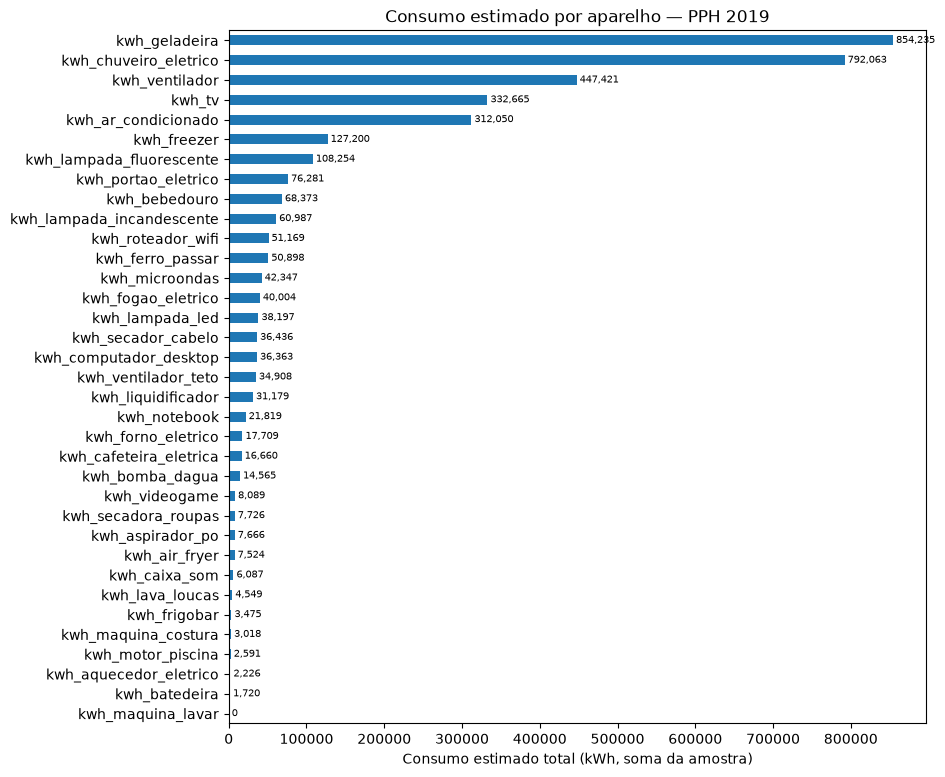

In [18]:
ax = total_por_aparelho.sort_values().plot(kind="barh", figsize=(9, 9))
ax.set_xlabel("Consumo estimado total (kWh, soma da amostra)")
ax.set_title("Consumo estimado por aparelho — PPH 2019")
for i, v in enumerate(total_por_aparelho.sort_values()):
    ax.text(v, i, f" {v:,.0f}", va="center", fontsize=7)


## 11. Exportação dos arquivos `.csv`

1. **`consumo_energetico_completo.csv`** — tabela completa (identificação +
   quantidades + consumo por aparelho + consumo total + valor estimado da
   conta).
2. **`consumo_top3_aparelhos.csv`** — identificação + quantidade/consumo
   apenas dos 3 aparelhos que mais consumiram energia + consumo
   total/valor da conta.
3. **`consumo_categoria_top.csv`** — identificação + quantidade/consumo
   apenas dos aparelhos da categoria que mais consumiu energia + consumo
   total/valor da conta.


In [19]:
OUT_DIR = Path("output")
OUT_DIR.mkdir(exist_ok=True)

COLUNAS_GERAIS = ["consumo_total_kwh_mes", "valor_estimado_conta_reais"]

# 1) Tabela completa
df_final.to_csv(OUT_DIR / "consumo_energetico_completo.csv", index=False, encoding="utf-8-sig")

# 2) Top 3 aparelhos
sufixos_top3 = [c.replace("kwh_", "") for c in top3_aparelhos.index]
colunas_top3 = ["ENTREVISTA", "REGIAO", "UF", "MUNICIPIO"]
for suf in sufixos_top3:
    colunas_top3 += [c for c in (f"qtd_{suf}", f"kwh_{suf}") if c in df_final.columns]
colunas_top3 += COLUNAS_GERAIS
df_final[colunas_top3].to_csv(OUT_DIR / "consumo_top3_aparelhos.csv", index=False, encoding="utf-8-sig")

# 3) Categoria que mais consumiu
cols_categoria_top = CATEGORIAS[categoria_top]
colunas_cat_top = ["ENTREVISTA", "REGIAO", "UF", "MUNICIPIO"]
for c in cols_categoria_top:
    suf = c.replace("kwh_", "")
    colunas_cat_top += [x for x in (f"qtd_{suf}", f"kwh_{suf}") if x in df_final.columns]
colunas_cat_top += COLUNAS_GERAIS
df_final[colunas_cat_top].to_csv(OUT_DIR / "consumo_categoria_top.csv", index=False, encoding="utf-8-sig")

print("Arquivos gerados em:", OUT_DIR.resolve())
for f in sorted(OUT_DIR.glob("*.csv")):
    print(" -", f.name)


Arquivos gerados em: C:\Users\Usuario\Desktop\NOTEBOOK UPDATES\G9-BR-TEAM-18\notebooks\output
 - consumo_categoria_top.csv
 - consumo_energetico_completo.csv
 - consumo_top3_aparelhos.csv


## 12. Conclusão

- A tabela `consumo_energetico_completo.csv` cobre **36 aparelhos**
  em 6 categorias, com quantidade (inteiro), consumo individual (kWh/mês),
  consumo total por entrevista e valor estimado da conta de luz (R$).
- Todas as potências assumidas estão centralizadas nas Seções 3 a 8.
